# Unsupervised Learning

### Why PCA?
Imagine a dataset with many features. Visualizing or training models in high dimensions is complex and computationally heavy. PCA helps us project this high-dimensional data into a lower-dimensional space while retaining as much variance (information) as possible.

Let's build it from scratch using pure NumPy!

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Set seed for reproducibility
np.random.seed(42)

### 1. Loading the Dataset
We will use the classic **Iris Dataset**. It contains measurements for three iris species, with **4 features** per sample (sepal length, sepal width, petal length, petal width).

We will use PCA to study how much information each principal component captures before choosing how much to reduce.

In [3]:
# Load the iris dataset
iris_data = load_iris()
X = iris_data.data
y = iris_data.target  # We will hide this and only use it for the final plot!

print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

Dataset shape: (150, 4)
Number of features: 4


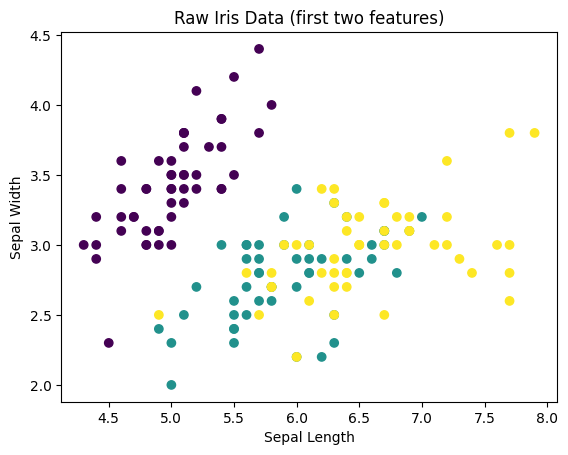

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Raw Iris Data (first two features)')
plt.show()

### Step 1: Standardization (Centering and Scaling)
Because our features have very different scales (e.g., one feature might be in the thousands, while another is a fraction), the larger features will artificially dominate the variance.

**Task:** Subtract the mean and divide by the standard deviation for each feature.

In [5]:
# Calculate the mean and standard deviation of each feature (column)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_std = np.where(X_std == 0, 1, X_std)  
# Standardize the data
X_scaled = (X - X_mean) / X_std

print("Mean of scaled data (should be close to 0):", np.mean(X_scaled, axis=0))
print("Std of scaled data (should be close to 1):", np.std(X_scaled, axis=0))

Mean of scaled data (should be close to 0): [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std of scaled data (should be close to 1): [1. 1. 1. 1.]


### Step 2: The Covariance Matrix
To understand how our 4 features vary together, we compute the covariance matrix.
**Task:** Compute the covariance matrix of the scaled data.

In [6]:
# Compute the covariance matrix
cov_matrix = (X_scaled.T @ X_scaled) / (X_scaled.shape[0] - 1)

print("Covariance Matrix shape:", cov_matrix.shape)

Covariance Matrix shape: (4, 4)


### Step 3: Eigen-decomposition
We need to find the directions (Principal Components) where the data varies the most. These directions are the **eigenvectors** of the covariance matrix, and their corresponding **eigenvalues** tell us the magnitude of the variance in that direction.

**Task:** Compute the eigenvalues and eigenvectors.

In [7]:
# Compute eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("Number of eigenvalues:", len(eigenvalues))

Number of eigenvalues: 4


### Step 4: Sorting Principal Components
The eigenvectors with the highest eigenvalues contain the most information. We need to sort them in descending order.

**Task:** Sort the eigenvalues and their corresponding eigenvectors.

In [8]:
# Get the indices that would sort the eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

# Sort eigenvalues and eigenvectors using the indices
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Each PC's contribution and running (cumulative) contribution
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Top 3 Eigenvalues:", sorted_eigenvalues[:3])
print("Top 3 explained variance ratios:", explained_variance_ratio[:3])
print("Cumulative explained variance (all PCs):", cumulative_explained_variance)

Top 3 Eigenvalues: [2.93808505 0.9201649  0.14774182]
Top 3 explained variance ratios: [0.72962445 0.22850762 0.03668922]
Cumulative explained variance (all PCs): [0.72962445 0.95813207 0.99482129 1.        ]


### Step 6: Candidate Contribution Plot
Let's see **which principal components contribute how much**.

**Task:** Plot both:
- Individual contribution of each PC (`explained_variance_ratio`)
- Cumulative contribution (`cumulative_explained_variance`)

Example thresholds to compare: **95%** and **98%**.

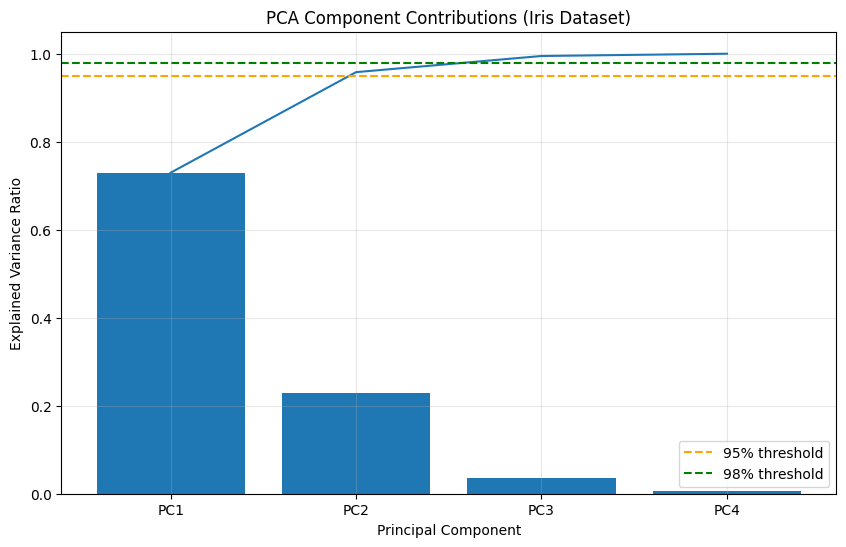

In [9]:
n_components = len(sorted_eigenvalues)
pc_indices = np.arange(1, n_components + 1) 

plt.figure(figsize=(10, 6))

# Individual contribution as bars
plt.bar(pc_indices, explained_variance_ratio)

plt.plot(pc_indices, cumulative_explained_variance)

# Guide lines
plt.axhline(0.95, color='orange', linestyle='--', linewidth=1.5, label='95% threshold')
plt.axhline(0.98, color='green', linestyle='--', linewidth=1.5, label='98% threshold')

plt.xticks(pc_indices, [f'PC{i}' for i in pc_indices])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Component Contributions (Iris Dataset)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Step 7: Picking the top $k$ eigenvectors

In [13]:
# Pick a target variance (try 0.95 or 0.98)
target_variance = 0.99

# Find the minimum number of PCs needed to reach target_variance
k = np.argmax(cumulative_explained_variance >= target_variance) + 1

eigenvector_subset = sorted_eigenvectors[:, :k]  

# Project standardized data onto selected eigenvectors -> PC scores
X_reduced = X_scaled @ eigenvector_subset  
X_reduced += np.mean(X[:,:k],axis=0)
print(f"Chosen target variance: {target_variance * 100:.0f}%")
print(f"Selected k: {k}")
print(f"Retained variance: {cumulative_explained_variance[k-1]:.4f}")
print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)

Chosen target variance: 99%
Selected k: 3
Retained variance: 0.9948
Original shape: (150, 4)
Reduced shape: (150, 3)


### Step 8. Visualize the Reduced Data (2D)
Now we will visualize the transformed data.

If `k >= 2`, we plot the first two principal components.

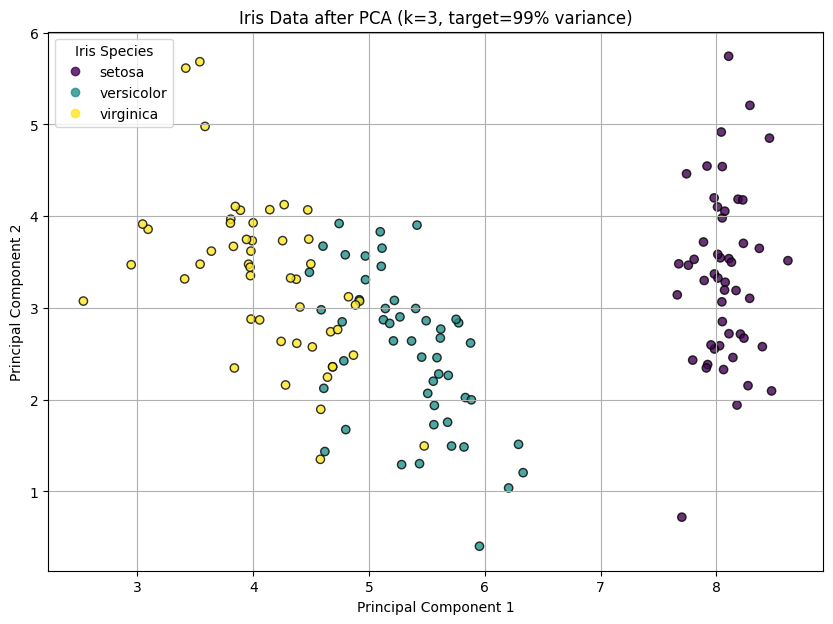

In [14]:
plt.figure(figsize=(10, 7))

if X_reduced.shape[1] >= 2:
    x_axis = X_reduced[:, 0]
    y_axis = X_reduced[:, 1]
    x_label = "Principal Component 1"
    y_label = "Principal Component 2"
else:
    x_axis = X_reduced[:, 0]
    y_axis = np.zeros_like(X_reduced[:, 0])
    x_label = "Principal Component 1"
    y_label = "Zero axis (only 1 PC retained)"

# Scatter plot colored by the actual iris classes
scatter = plt.scatter(x_axis, y_axis, c=y, cmap='viridis', alpha=0.8, edgecolor='k')

plt.legend(handles=scatter.legend_elements()[0],
           labels=iris_data.target_names.tolist(),
           title="Iris Species")

plt.title(f"Iris Data after PCA (k={k}, target={target_variance*100:.0f}% variance)")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.grid(True)
plt.show()

Text(0.5, 0.92, 'Iris PCA — 3D View\nTotal variance explained: 99.5%')

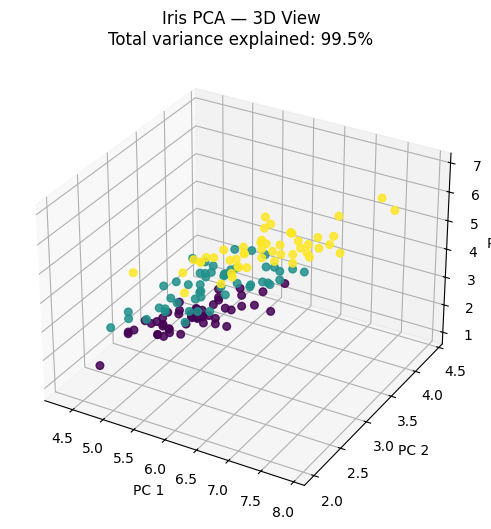

In [19]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter3D(X[:,0],X[:,1],X[:,2],c=y,s=30,alpha=0.85)

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Iris PCA — 3D View\n'f'Total variance explained: {cumulative_explained_variance[2]*100:.1f}%')